##Importing Libraries

In [39]:
import pandas as pd ## Data Manipulation
import numpy as np ## Mathematical Calculations

##Data Ingestion

In [40]:
# Load the data
data_path="/content/drive/MyDrive/1782321019230_Patient_Readmission.xlsx"

df=pd.read_excel(data_path)

display(df)


,Patient ID,Age,Gender,Admission Type,Length of Stay,Number of Diagnoses,Blood Pressure,Blood Sugar Levels,Previous Admissions,Readmission
0,1,62,Female,Elective,4,5,110,130,1,No
1,2,65,Male,Emergency,19,2,157,81,4,No
2,3,82,Female,Emergency,18,4,74,84,0,No
3,4,85,Male,Emergency,2,4,106,85,4,No
4,5,85,Female,Elective,19,3,80,119,3,No
...,...,...,...,...,...,...,...,...,...,...
2995,2996,50,Female,Emergency,4,2,150,143,0,No
2996,2997,21,Female,Elective,1,2,141,169,1,No
2997,2998,20,Female,Elective,2,8,155,180,3,No
2998,2999,69,Female,Elective,13,9,117,173,4,Yes


In [41]:
# Display the number of rows and columns
df.shape

(3000, 10)

Observation

The dataset consists of 3000 patient records and 10 columns.

In [42]:
# Check the column names in the dataset
df.columns

Index(['Patient ID', 'Age', 'Gender', 'Admission Type', 'Length of Stay',
       'Number of Diagnoses', 'Blood Pressure', 'Blood Sugar Levels',
       'Previous Admissions', 'Readmission'],
      dtype='object')

Observation

The dataset contains both categorical and numerical variables

In [43]:
# View the data types
df.dtypes

,0
Patient ID,int64
Age,int64
Gender,object
Admission Type,object
Length of Stay,int64
Number of Diagnoses,int64
Blood Pressure,int64
Blood Sugar Levels,int64
Previous Admissions,int64
Readmission,object


Observation

The dataset contains seven integer columns and three object columns. Integer is a whole number without decimals. An object is a string which is a combination of characters.

In [44]:
# Display the missing values in the dataset.
df.isnull().sum()

,0
Patient ID,0
Age,0
Gender,0
Admission Type,0
Length of Stay,0
Number of Diagnoses,0
Blood Pressure,0
Blood Sugar Levels,0
Previous Admissions,0
Readmission,0


Observation

 There are no missing values in the dataset.


In [45]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

Observation

There are no repeated rows in the dataset.

In [46]:
# Display summary statistics for categorical columns
df.describe(include='object')

,Gender,Admission Type,Readmission
count,3000,3000,3000
unique,2,2,2
top,Male,Elective,No
freq,1555,1563,2134


Observation

The categorical columns show the same number of categories. Male gender appears frequently than female. The most common admission type is elective and most patients in the dataset were not readmitted.

In [47]:
# Count the number of patients by gender
df['Gender'].value_counts()

,count
Gender,
Male,1555
Female,1445


Observation

The number of male and female patients is relatively similar with only a difference of 110 patients between the two groups.

In [48]:
# Check the age range of patients in the dataset
df['Age'].min(), df['Age'].max()



(18, 89)

Observation

The age of patients ranges from 18 years to 89 years old.

In [49]:
# Create age groups to check the distribution of patients by age (using pandas case statement)
conditions = [
    df['Age'] < 25,
    df['Age'] .between (25, 40),
    df['Age'] .between (41, 60),
    df['Age'] .between (61, 80),
    df['Age'] > 80

]
choices = [
    'Youth',
    'Young Adults',
    'Adults',
    'Senior',
    'Old'

]
df['Age Group'] = np.select(conditions ,choices, default='Unknown')

In [50]:
# count patients per age group
df['Age Group'].value_counts()

,count
Age Group,
Senior,835
Adults,824
Young Adults,692
Old,370
Youth,279


Observation

Seniors make up the largest age group in the dataset 835 patients and youth being the lowest age group.

In [51]:
# View the age groups by Admission Type (Emergency vs Elective)
pd.crosstab(df['Admission Type'], df['Age Group'])

Age Group,Adults,Old,Senior,Young Adults,Youth
Admission Type,,,,,
Elective,413,187,452,365,146
Emergency,411,183,383,327,133


Observation

There are fewer emergency patients in each age group than elective patients.

##Data Visualisation

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px

In [53]:
df.columns

Index(['Patient ID', 'Age', 'Gender', 'Admission Type', 'Length of Stay',
       'Number of Diagnoses', 'Blood Pressure', 'Blood Sugar Levels',
       'Previous Admissions', 'Readmission', 'Age Group'],
      dtype='object')

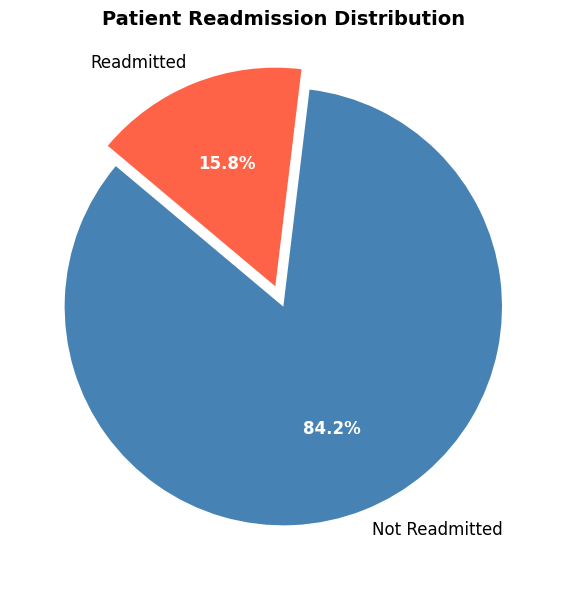

In [54]:
import matplotlib.pyplot as plt

## Shows the percentages of patients which were readmitted versus not readmitted

# 1. Prepare data (Example percentages)
labels = ['Not Readmitted', 'Readmitted']
percentages = [84.2, 15.8]
colors = ['#4682B4', '#FF6347'] # Steel blue and tomato red
explode = (0, 0.1)  # Slightly separate the 'Readmitted' slice

# 2. Create the pie chart
plt.figure(figsize=(6, 6))
patches, texts, autotexts = plt.pie(
    percentages,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',  # Automatically calculates and formats the percentage
    startangle=140,     # Rotates the start of the pie chart for better aesthetics
    textprops={'fontsize': 12}
)

# 3. Customize percentage text inside the slices for readability
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

# 4. Add title and display
plt.title("Patient Readmission Distribution", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


Observation

The patient readmission shows that 15.8% of patients were readmitted and 84,2% were not readmitted. This indicate that the dataset is imbalanced.

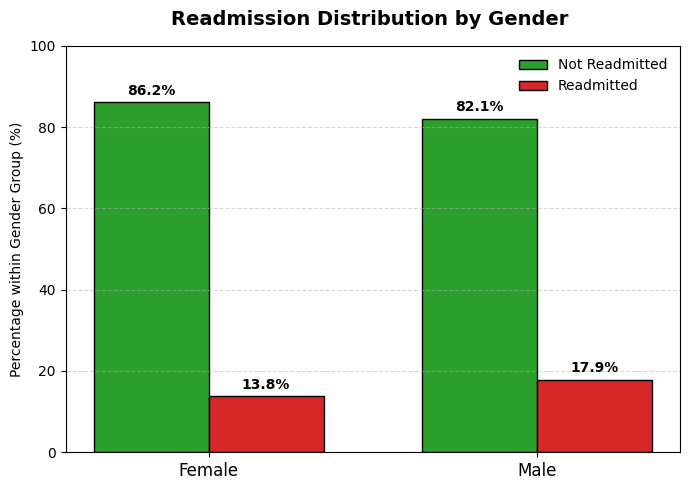

In [55]:
# Shows the patients readmission distribution by gender

import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare data (Example percentages normalized within each gender group)
genders = ['Female', 'Male']
not_readmitted_pct = [86.2, 82.1]  # Percentage of each gender group not readmitted
readmitted_pct = [13.8, 17.9]      # Percentage of each gender group readmitted

x = np.arange(len(genders))  # Label locations: [0, 1]
width = 0.35                 # Width of each bar inside the group

# 2. Initialize the plot
fig, ax = plt.subplots(figsize=(7, 5))

# 3. Draw side-by-side bars
bars1 = ax.bar(x - width/2, not_readmitted_pct, width, label='Not Readmitted', color='#2ca02c', edgecolor='black')
bars2 = ax.bar(x + width/2, readmitted_pct, width, label='Readmitted', color='#d62728', edgecolor='black')

# 4. Attach percentage value labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', weight='bold')

add_labels(bars1)
add_labels(bars2)

# 5. Format labels, title, and layout
ax.set_title('Readmission Distribution by Gender ', fontsize=14, weight='bold', pad=15)
ax.set_ylabel('Percentage within Gender Group (%)')
ax.set_xticks(x)
ax.set_xticklabels(genders, fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()


Observation

The graph shows that male patients have a higher readmission rate than female patients. However, female patients have a higher rate of non-admission than male patients.

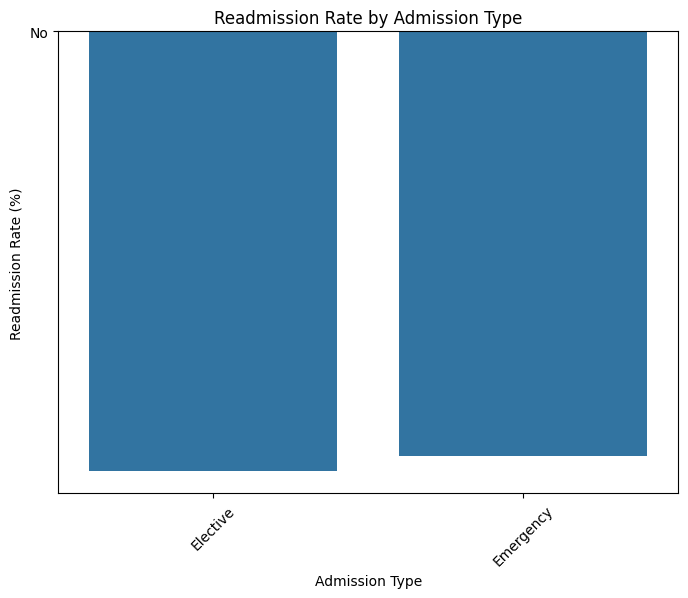

In [56]:
# View the patients who were readmitted according to admission type
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(8, 6))

# Specifying errorbar=None removes confidence interval lines if they aren't needed
# If 'readmitted' is binary (1 for Yes, 0 for No), this shows the actual rate (0.0 to 1.0)
sns.barplot(
    data=df,
    x="Admission Type",
    y="Readmission",
    errorbar=None

)

plt.title("Readmission Rate by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Readmission Rate (%)")

# Format y-axis as percentages
ax.yaxis.set_major_formatter(PercentFormatter(1))

#Add percentage values on top of the bars
for container in ax.containers:
  labels = [f'{bar.get_height() * 100:.1f}%'for bar in container]
  ax.bar_label(container, labels=labels,padding=3)

plt.xticks(rotation=45)
plt.show()


Observation

Patients admitted through emergency services had a slightly higher readmission rate compared to patients admitted electively.

In [57]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib as plt

In [58]:
# Check if there is a relationship between a patient's age and the number of days they stayed in the hospital

fig=px.scatter(df, x='Age', y='Length of Stay', color='Gender', title='Age vs Length of Stay')
fig.update_traces(marker=dict(size=4))

Observation

The scatter plot suggest that there is no clear relationship between age and length of stay. This indicate that age alone may not be a strong predictor of how long a patient remains in the hospital.

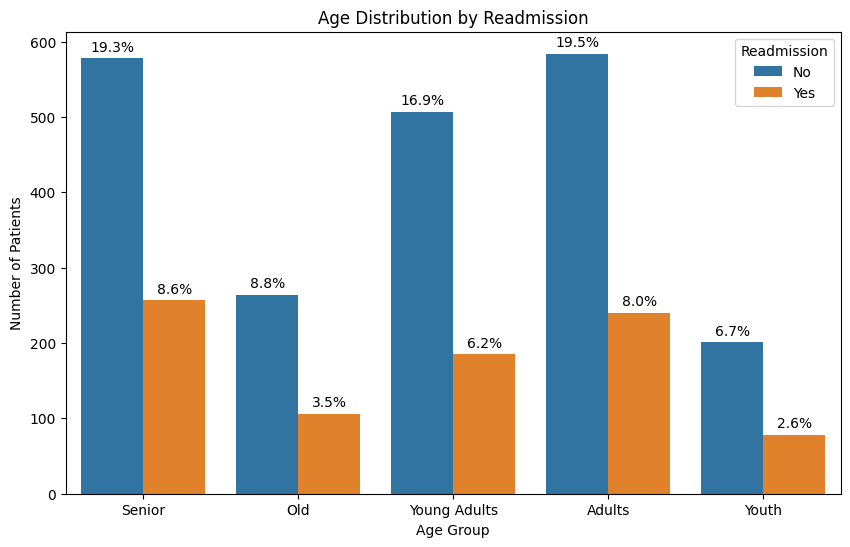

In [59]:
# View age group distribution by readmission

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x='Age Group',
    hue='Readmission'
)

plt.title('Age Distribution by Readmission')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')

# Add percentage labels
total = len(df)

for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        percentage = (height / total) * 100
        labels.append(f'{percentage:.1f}%')

    ax.bar_label(container, labels=labels, padding=3)

plt.show()

Observation

Adults have the highest number of patients while youth have the lowest. Across all age groups, non-readmitted patients are more numerous than readmitted patients.

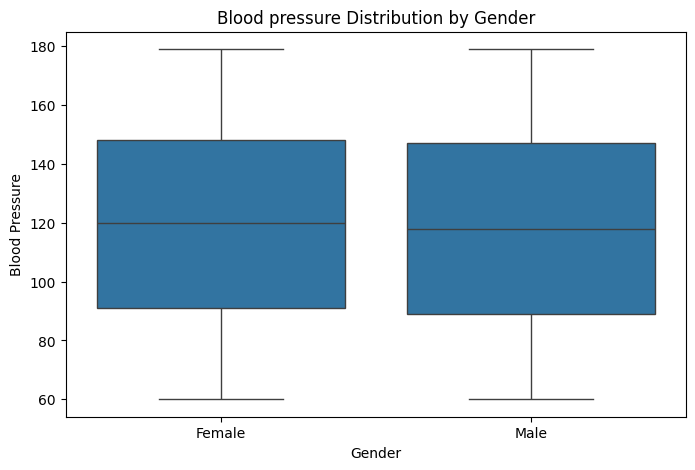

In [60]:
# Check the blood pressure by gender

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Gender',
    y='Blood Pressure'
)
plt.title('Blood pressure Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Blood Pressure')
plt.show()

Observation

The box plot shows that blood pressure distribution are very similar between male and female patients.

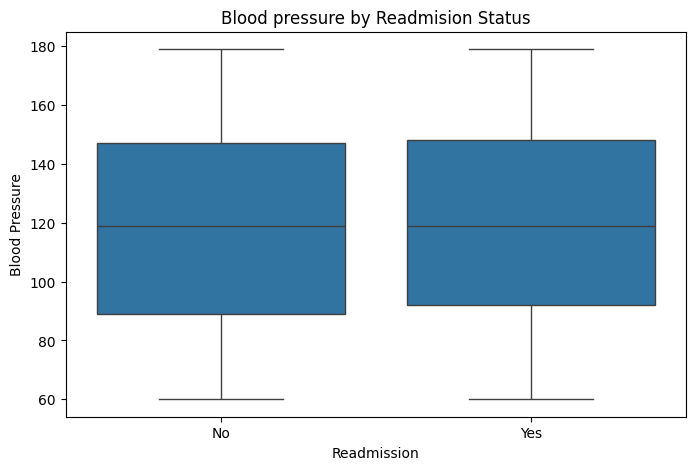

In [61]:
# Check blood pressure distribution by readmission status

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Readmission',
    y='Blood Pressure'
)
plt.title('Blood pressure by Readmision Status')
plt.show()

Observation

The box plot shows that blood pressure distributions are similar between readmitted and non-readmitted patients. This suggests that blood pressure alone may not be a strong distinguishing factor for readmission in this dataset.

/tmp/ipykernel_741/1094277081.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




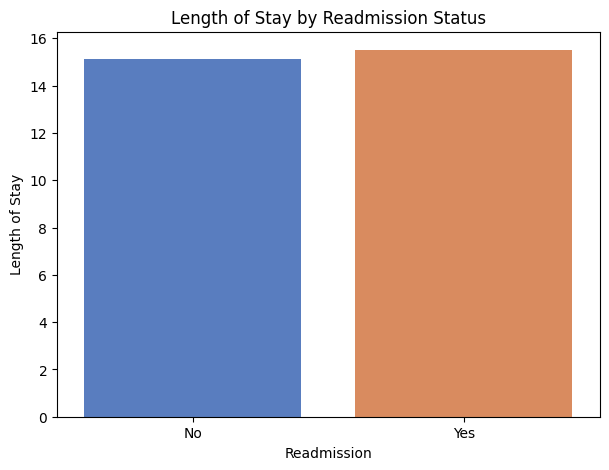

In [62]:
# Display length of Stay by Readmission

plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x='Readmission',
    y='Length of Stay',
    errorbar=None,
    palette='muted'
)
plt.title('Length of Stay by Readmission Status')
plt.xlabel('Readmission')
plt.ylabel('Length of Stay')
plt.show()

Observation

The average length of stay is nearly the same for readmitted and non-readmitted patients, suggesting that length of stay alone may not have a strong relationship with readmission in this dataset.

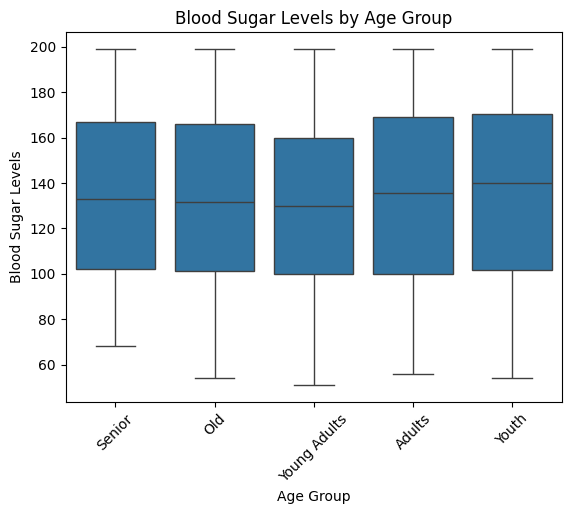

In [63]:
# Display the Blood Sugar patients by Age Group

sns.boxplot(
    data=df,
    x='Age Group',
    y='Blood Sugar Levels'
)

plt.title('Blood Sugar Levels by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Blood Sugar Levels')
plt.xticks(rotation=45)
plt.show()

Observation

Blood sugar levels vary across the different age groups. However, young adults age group is slightly lower compared to the rest of the groups.

In [64]:
# Shows the percentage distribution of previous admissions within each age group
percentage_df = pd.crosstab(
    df['Age Group'],
    df['Previous Admissions'],
    normalize='index'
) * 100

percentage_df

Previous Admissions,0,1,2,3,4
Age Group,,,,,
Adults,18.932039,24.029126,18.932039,19.174757,18.932039
Old,20.540541,22.432432,18.108108,21.081081,17.837838
Senior,20.000000,19.760479,21.317365,20.479042,18.443114
Young Adults,20.520231,21.676301,18.063584,21.098266,18.641618
Youth,20.430108,21.505376,19.354839,18.637993,20.071685


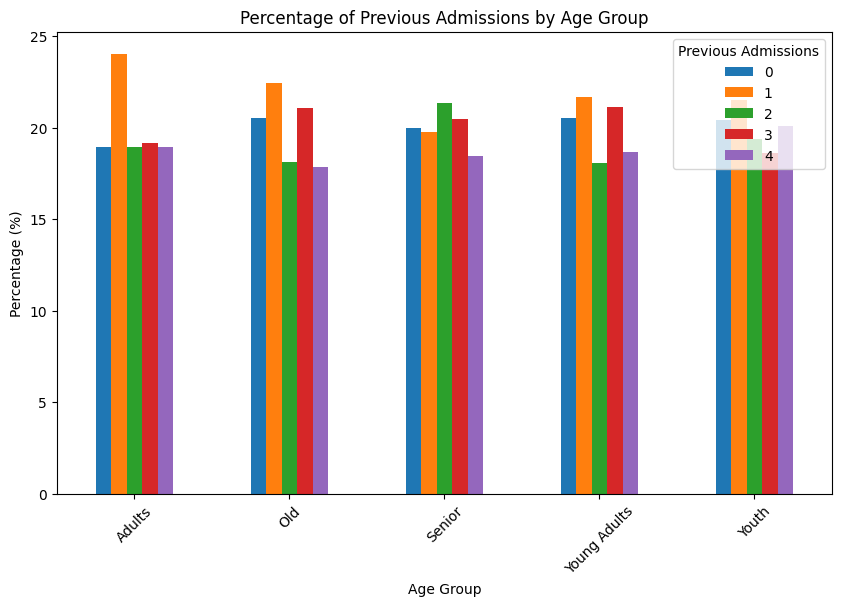

In [65]:
# The graph presents the percentage distribution of previous admissions across different age groups

percentage_df.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Percentage of Previous Admissions by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Previous Admissions')
plt.show()

Observation

The percentage distribution shows differences in previous-admission patterns across age groups. The most common number of previous admissions varies between age groups, while the chart also highlights the proportion of patients with multiple previous admissions.